## 0. 데이터 처리 워크플로우 재시작 (런타임 재시작 후 모든 셀 순서대로 실행 권장)

In [12]:
import sqlite3
import pandas as pd
import re

# 단일 인메모리 SQLite 데이터베이스 연결
conn_main = sqlite3.connect(':memory:')

# SQLite에 LPAD 사용자 정의 함수 등록
def lpad_sqlite(text, length, pad_char):
    text = str(text) if text is not None else ''
    return text.zfill(length)

conn_main.create_function("LPAD", 3, lpad_sqlite)

print("SQLite 데이터베이스 연결 성공! LPAD 함수 등록 완료!")

# 회사명 정규화 함수 정의 (중복 방지를 위해 여기에 한 번만 정의)
def clean_company_name(name):
    if not isinstance(name, str):
        return name

    # 띄어쓰기 제거
    cleaned_name = re.sub(r'\s+', '', name)

    # 앞쪽 법인 형태 제거
    cleaned_name = re.sub(
        r'^(?:\(재\)|\(주\)|\(유\)|유한책임회사|주식회사)',
        '',
        cleaned_name,
        flags=re.IGNORECASE
    )

    # 뒤쪽 법인 형태 제거
    cleaned_name = re.sub(
        r'(?:\(재\)|\(주\)|\(유\)|유한책임회사|주식회사|회사)$',
        '',
        cleaned_name,
        flags=re.IGNORECASE
    )

    # ㈜ 제거
    cleaned_name = cleaned_name.replace('㈜', '')

    # 대문자 통일
    return cleaned_name.upper()

SQLite 데이터베이스 연결 성공! LPAD 함수 등록 완료!


### 1. Excel 파일 로드 및 전처리

In [13]:
# Google Drive에서 Excel 파일 로드
file_path = '/content/drive/MyDrive/온실가스 에너지 목표관리 명세서 주요정보.xls'
try:
    df_excel = pd.read_excel(file_path)

    # 컬럼 이름이 '지정업종(목표)/<br />계획업종(할당)' 인지 확인하고 변경
    original_col_name = None
    for col in df_excel.columns:
        if '지정업종(목표)/' in col and '계획업종(할당)' in col:
            original_col_name = col
            break

    if original_col_name:
        df_excel.rename(columns={original_col_name: '지정업종_상세'}, inplace=True)
        print(f"컬럼 '{original_col_name}'을 '지정업종_상세'로 변경 완료!")
    else:
        print("경고: '지정업종(목표)/계획업종(할당)' 또는 유사한 컬럼을 찾을 수 없습니다.")

    print("Excel 파일 로드 성공!")
    display(df_excel.head())

    # df_excel을 SQL 테이블로 저장
    df_excel.to_sql('greenhouse_gas_data', conn_main, index=False, if_exists='replace')
    print("df_excel을 SQLite 테이블 'greenhouse_gas_data'로 성공적으로 저장했습니다.")

except FileNotFoundError:
    print(f"오류: 파일을 찾을 수 없습니다. 경로를 확인해주세요: {file_path}")
    df_excel = pd.DataFrame() # 오류 발생 시 빈 DataFrame으로 초기화
except Exception as e:
    print(f"Excel 파일 로드 중 오류 발생: {e}")
    df_excel = pd.DataFrame() # 오류 발생 시 빈 DataFrame으로 초기화

컬럼 '지정업종(목표)/<br />계획업종(할당)'을 '지정업종_상세'로 변경 완료!
Excel 파일 로드 성공!


,번호,관장기관,법인명,대상년도,지정구분,지정업종_상세,온실가스 배출량(tCO₂eq),에너지 사용량(TJ),검증수행기관,비고
0,1,기후에너지환경부,롯데이노베이트(주),2024,사업장,"컴퓨터 프로그래밍, 시스템 통합 및 관리업","120,487","2,514",한국표준협회,NaN
1,2,기후에너지환경부,리뉴에너지경인 주식회사,2024,사업장,폐기물 처리업,"51,427",12,(주)한국경영인증원,NaN
2,3,기후에너지환경부,(유)남해환경,2024,사업장,폐기물 처리업,"27,986",178,(재)한국품질재단,NaN
3,4,기후에너지환경부,(유)에보닉페록사이드코리아,2024,사업장,기초 화학물질 제조업,"36,818",734,(재)한국품질재단,"""(유)에스케이보닉페록사이드코리아"" 업체명 변경"
4,5,기후에너지환경부,(유)청명,2024,사업장,폐기물,"25,597",511,㈜한국품질보증원,NaN


df_excel을 SQLite 테이블 'greenhouse_gas_data'로 성공적으로 저장했습니다.


### 2. 필요한 컬럼 추출

In [14]:
if not df_excel.empty:
    sql_query = """
    SELECT
        "법인명",
        "지정구분",
        "지정업종_상세",
        "온실가스 배출량(tCO₂eq)",
        "에너지 사용량(TJ)"
    FROM greenhouse_gas_data
    """

    df_selected = pd.read_sql_query(sql_query, conn_main)
    print("SQL 쿼리 결과 (df_selected):")
    display(df_selected.head())
else:
    print("df_excel이 비어있어 컬럼 추출을 실행할 수 없습니다.")
    df_selected = pd.DataFrame()

SQL 쿼리 결과 (df_selected):


,법인명,지정구분,지정업종_상세,온실가스 배출량(tCO₂eq),에너지 사용량(TJ)
0,롯데이노베이트(주),사업장,"컴퓨터 프로그래밍, 시스템 통합 및 관리업","120,487","2,514"
1,리뉴에너지경인 주식회사,사업장,폐기물 처리업,"51,427",12
2,(유)남해환경,사업장,폐기물 처리업,"27,986",178
3,(유)에보닉페록사이드코리아,사업장,기초 화학물질 제조업,"36,818",734
4,(유)청명,사업장,폐기물,"25,597",511


### 3. KOSPI 데이터 로드 및 조인

In [15]:
if not df_selected.empty:
    kospi_file_path = '/content/drive/MyDrive/KOSPI업종분류현황.csv' # 올바른 파일 경로
    try:
        df_kospi = pd.read_csv(kospi_file_path, encoding='cp949')
        print("KOSPI 업종 분류 현황 파일 로드 성공!")
        display(df_kospi.head())

        df_selected['cleaned_법인명'] = df_selected['법인명'].apply(clean_company_name)
        df_kospi['cleaned_종목명'] = df_kospi['종목명'].apply(clean_company_name)

        df_selected.to_sql('greenhouse_selected', conn_main, index=False, if_exists='replace')
        df_kospi.to_sql('kospi_info', conn_main, index=False, if_exists='replace')

        sql_join_query = """
        SELECT
            gs."cleaned_법인명" AS "법인명",
            gs."지정구분",
            gs."지정업종_상세",
            gs."온실가스 배출량(tCO₂eq)",
            gs."에너지 사용량(TJ)",
            ki."종목코드"
        FROM
            greenhouse_selected AS gs
        LEFT JOIN
            kospi_info AS ki
        ON
            gs."cleaned_법인명" = ki."cleaned_종목명"
        WHERE
            REPLACE(gs."온실가스 배출량(tCO₂eq)", ',', '') IS NOT NULL
            AND CAST(REPLACE(gs."온실가스 배출량(tCO₂eq)", ',', '') AS REAL) > 0
        """

        df_final = pd.read_sql_query(sql_join_query, conn_main)
        print("데이터 조인 및 필터링 성공 (df_final):")
        display(df_final.head())

    except FileNotFoundError:
        print(f"오류: KOSPI 파일을 찾을 수 없습니다. 경로를 확인해주세요: {kospi_file_path}")
        df_kospi = pd.DataFrame()
        df_final = pd.DataFrame()
    except Exception as e:
        print(f"KOSPI 파일 로드 또는 조인 중 오류 발생: {e}")
        df_kospi = pd.DataFrame()
        df_final = pd.DataFrame()
else:
    print("df_selected가 비어있어 KOSPI 조인을 실행할 수 없습니다.")
    df_final = pd.DataFrame()

KOSPI 업종 분류 현황 파일 로드 성공!


,종목코드,종목명,시장구분,업종명,종가,대비,등락률,시가총액
0,095570,AJ네트웍스,KOSPI,일반서비스,4660,35,0.76,210877856940
1,006840,AK홀딩스,KOSPI,기타금융,8710,-140,-1.58,115386256310
2,027410,BGF,KOSPI,기타금융,3920,25,0.64,375209820720
3,282330,BGF리테일,KOSPI,유통,104800,-1100,-1.04,1811353348800
4,138930,BNK금융지주,KOSPI,기타금융,15870,-170,-1.06,4989927193980


데이터 조인 및 필터링 성공 (df_final):


,법인명,지정구분,지정업종_상세,온실가스 배출량(tCO₂eq),에너지 사용량(TJ),종목코드
0,롯데이노베이트,사업장,"컴퓨터 프로그래밍, 시스템 통합 및 관리업","120,487","2,514",286940
1,리뉴에너지경인,사업장,폐기물 처리업,"51,427",12,None
2,남해환경,사업장,폐기물 처리업,"27,986",178,None
3,에보닉페록사이드코리아,사업장,기초 화학물질 제조업,"36,818",734,None
4,청명,사업장,폐기물,"25,597",511,None


### 4. KOSDAQ 데이터 로드 및 조인

In [16]:
if not df_final.empty:
    kosdaq_file_path = '/content/drive/MyDrive/KOSDAQ업종분류현황.csv'
    try:
        df_kosdaq = pd.read_csv(kosdaq_file_path, encoding='cp949')
        print("KOSDAQ 업종 분류 현황 파일 로드 성공!")
        display(df_kosdaq.head())

        df_final['cleaned_법인명'] = df_final['법인명'].apply(clean_company_name)
        df_kosdaq['cleaned_종목명'] = df_kosdaq['종목명'].apply(clean_company_name)

        df_final.to_sql('final_combined_data', conn_main, index=False, if_exists='replace')
        df_kosdaq.to_sql('kosdaq_data', conn_main, index=False, if_exists='replace')

        sql_kosdaq_join_query = """
        SELECT
            COALESCE(kd."종목코드", fcd."종목코드") AS "종목코드",
            fcd."cleaned_법인명" AS "법인명",
            fcd."지정구분",
            fcd."지정업종_상세",
            fcd."온실가스 배출량(tCO₂eq)",
            fcd."에너지 사용량(TJ)"
        FROM
            final_combined_data AS fcd
        LEFT JOIN
            kosdaq_data AS kd
        ON
            fcd."cleaned_법인명" = kd."cleaned_종목명"
        """

        df_final_with_kosdaq = pd.read_sql_query(sql_kosdaq_join_query, conn_main)
        print("KOSDAQ 데이터 조인 성공 (df_final_with_kosdaq):")
        display(df_final_with_kosdaq.head())

    except FileNotFoundError:
        print(f"오류: KOSDAQ 파일을 찾을 수 없습니다. 경로를 확인해주세요: {kosdaq_file_path}")
        df_kosdaq = pd.DataFrame()
        df_final_with_kosdaq = df_final.copy() # KOSDAQ 데이터 로드 실패 시 df_final을 그대로 사용
    except Exception as e:
        print(f"KOSDAQ 파일 로드 또는 조인 중 오류 발생: {e}")
        df_kosdaq = pd.DataFrame()
        df_final_with_kosdaq = df_final.copy()
else:
    print("df_final이 비어있어 KOSDAQ 조인을 실행할 수 없습니다.")
    df_final_with_kosdaq = pd.DataFrame()

KOSDAQ 업종 분류 현황 파일 로드 성공!


,종목코드,종목명,시장구분,업종명,종가,대비,등락률,시가총액
0,060310,3S,KOSDAQ,의료·정밀기기,1555,52,3.46,82506807200
1,054620,APS,KOSDAQ,금융,4060,-60,-1.46,74680537260
2,265520,AP시스템,KOSDAQ,기계·장비,19370,-60,-0.31,291534402770
3,211270,AP위성,KOSDAQ,전기·전자,12670,-30,-0.24,191092791680
4,139050,BF랩스,KOSDAQ,IT 서비스,2805,0,0.00,24247965555


KOSDAQ 데이터 조인 성공 (df_final_with_kosdaq):


,종목코드,법인명,지정구분,지정업종_상세,온실가스 배출량(tCO₂eq),에너지 사용량(TJ)
0,286940,롯데이노베이트,사업장,"컴퓨터 프로그래밍, 시스템 통합 및 관리업","120,487","2,514"
1,None,리뉴에너지경인,사업장,폐기물 처리업,"51,427",12
2,None,남해환경,사업장,폐기물 처리업,"27,986",178
3,None,에보닉페록사이드코리아,사업장,기초 화학물질 제조업,"36,818",734
4,None,청명,사업장,폐기물,"25,597",511


### 5. '종목코드' 포맷팅

In [17]:
if 'df_final_with_kosdaq' in locals() and not df_final_with_kosdaq.empty:
    df_final_with_kosdaq['종목코드'] = df_final_with_kosdaq['종목코드'].astype(str).str.zfill(6)
    print("'종목코드' 컬럼이 6자리로 포맷되었습니다.")
    display(df_final_with_kosdaq.head())
else:
    print("df_final_with_kosdaq가 유효하지 않아 '종목코드' 포맷팅을 실행할 수 없습니다.")

'종목코드' 컬럼이 6자리로 포맷되었습니다.


,종목코드,법인명,지정구분,지정업종_상세,온실가스 배출량(tCO₂eq),에너지 사용량(TJ)
0,286940,롯데이노베이트,사업장,"컴퓨터 프로그래밍, 시스템 통합 및 관리업","120,487","2,514"
1,00None,리뉴에너지경인,사업장,폐기물 처리업,"51,427",12
2,00None,남해환경,사업장,폐기물 처리업,"27,986",178
3,00None,에보닉페록사이드코리아,사업장,기초 화학물질 제조업,"36,818",734
4,00None,청명,사업장,폐기물,"25,597",511


### 6. 최종 '업종명' 컬럼 추가 및 데이터 정리

In [18]:
if 'df_final_with_kosdaq' in locals() and not df_final_with_kosdaq.empty:
    # df_final_with_kosdaq에는 이미 '지정업종_상세' 컬럼이 포함되어 있습니다.
    # 이제 이를 '업종명'으로 변경하고 원하는 순서로 컬럼을 재정렬합니다.
    df_final_with_industry = df_final_with_kosdaq.rename(columns={'지정업종_상세': '업종명'})

    # 최종 컬럼 순서 지정
    final_columns = [
        "종목코드",
        "법인명",
        "지정구분",
        "업종명",
        "온실가스 배출량(tCO₂eq)",
        "에너지 사용량(TJ)"
    ]

    # 필요한 컬럼만 선택하고 순서를 맞춥니다.
    df_final_with_industry = df_final_with_industry[final_columns]

    print("최종 '업종명' 컬럼이 추가된 데이터:")
    display(df_final_with_industry.head())
else:
    print("df_final_with_kosdaq가 유효하지 않아 최종 업종명 병합을 실행할 수 없습니다.")
    df_final_with_industry = pd.DataFrame()

최종 '업종명' 컬럼이 추가된 데이터:


,종목코드,법인명,지정구분,업종명,온실가스 배출량(tCO₂eq),에너지 사용량(TJ)
0,286940,롯데이노베이트,사업장,"컴퓨터 프로그래밍, 시스템 통합 및 관리업","120,487","2,514"
1,00None,리뉴에너지경인,사업장,폐기물 처리업,"51,427",12
2,00None,남해환경,사업장,폐기물 처리업,"27,986",178
3,00None,에보닉페록사이드코리아,사업장,기초 화학물질 제조업,"36,818",734
4,00None,청명,사업장,폐기물,"25,597",511


### 7. `df_final_with_industry`를 `final_industry_data` 테이블로 저장

In [19]:
if 'df_final_with_industry' in locals() and not df_final_with_industry.empty:
    df_final_with_industry.to_sql('final_industry_data', conn_main, index=False, if_exists='replace')
    print("df_final_with_industry를 SQLite 테이블 'final_industry_data'로 성공적으로 저장했습니다.")
else:
    print("df_final_with_industry가 유효하지 않아 'final_industry_data' 테이블을 생성할 수 없습니다.")

df_final_with_industry를 SQLite 테이블 'final_industry_data'로 성공적으로 저장했습니다.


### 8. ESG 등급 데이터 로드 및 선택 컬럼 추출

In [20]:
esg_file_path = '/content/drive/MyDrive/(2024~2024)_평가등급(2026).xlsx'
try:
    df_esg = pd.read_excel(esg_file_path)
    print("ESG 등급 Excel 파일 로드 성공!")
    display(df_esg.head())

    # 요청된 컬럼만 선택
    esg_selected_columns = ['기업명', '기업코드', 'ESG등급', '환경', '사회', '지배구조']
    df_esg_selected = df_esg[esg_selected_columns]

    # cleaned_기업명 컬럼 추가
    df_esg_selected['cleaned_기업명'] = df_esg_selected['기업명'].apply(clean_company_name)

    print("선택된 ESG 컬럼:")
    display(df_esg_selected.head())

    # SQLite에 저장
    df_esg_selected.to_sql('esg_ratings', conn_main, index=False, if_exists='replace')
    print("df_esg_selected를 SQLite 테이블 'esg_ratings'로 성공적으로 저장했습니다.")

except FileNotFoundError:
    print(f"오류: ESG 파일을 찾을 수 없습니다. 경로를 확인해주세요: {esg_file_path}")
    df_esg_selected = pd.DataFrame()
except Exception as e:
    print(f"ESG 파일 로드 또는 처리 중 오류 발생: {e}")
    df_esg_selected = pd.DataFrame()

ESG 등급 Excel 파일 로드 성공!


/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,NO,기업명,기업코드,ESG등급,환경,사회,지배구조,평가년도,ESG 등급조정,환경 등급조정,사회 등급조정,지배구조 등급조정
0,1067.0,AJ네트웍스,95570.0,B+,C,A,B+,2024.0,NaN,NaN,NaN,NaN
1,1066.0,AK홀딩스,6840.0,A,A,A+,B+,2024.0,NaN,NaN,NaN,NaN
2,1065.0,BGF,27410.0,A,A,A+,B+,2024.0,NaN,NaN,NaN,NaN
3,1064.0,BGF리테일,282330.0,A,A,A+,A,2024.0,NaN,NaN,NaN,NaN
4,1063.0,BGF에코머티리얼즈,126600.0,B,B,B,B,2024.0,NaN,NaN,NaN,NaN


선택된 ESG 컬럼:


/tmp/ipykernel_63148/2086935256.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_esg_selected['cleaned_기업명'] = df_esg_selected['기업명'].apply(clean_company_name)


,기업명,기업코드,ESG등급,환경,사회,지배구조,cleaned_기업명
0,AJ네트웍스,95570.0,B+,C,A,B+,AJ네트웍스
1,AK홀딩스,6840.0,A,A,A+,B+,AK홀딩스
2,BGF,27410.0,A,A,A+,B+,BGF
3,BGF리테일,282330.0,A,A,A+,A,BGF리테일
4,BGF에코머티리얼즈,126600.0,B,B,B,B,BGF에코머티리얼즈


df_esg_selected를 SQLite 테이블 'esg_ratings'로 성공적으로 저장했습니다.


### 9. `final_industry_data`와 `esg_ratings` 테이블 `OUTER JOIN`

In [21]:
if 'conn_main' in globals():
    # SQLite에서 FULL OUTER JOIN을 시뮬레이션하기 위한 쿼리
    # esg_ratings의 '기업코드'는 float일 수 있으므로, INTEGER로 캐스팅 후 6자리 TEXT로 패딩
    sql_outer_join_query = """
    SELECT
        COALESCE(fid."종목코드", LPAD(CAST(CAST(er."기업코드" AS INTEGER) AS TEXT), 6, '0')) AS "종목코드",
        COALESCE(fid."법인명", er."cleaned_기업명") AS "법인명",
        fid."지정구분",
        fid."업종명",
        fid."온실가스 배출량(tCO₂eq)",
        fid."에너지 사용량(TJ)",
        er."ESG등급",
        er."환경",
        er."사회",
        er."지배구조"
    FROM
        final_industry_data AS fid
    LEFT JOIN
        esg_ratings AS er
    ON
        fid."종목코드" = LPAD(CAST(CAST(er."기업코드" AS INTEGER) AS TEXT), 6, '0')
    UNION ALL
    SELECT
        LPAD(CAST(CAST(er."기업코드" AS INTEGER) AS TEXT), 6, '0') AS "종목코드",
        er."cleaned_기업명" AS "법인명",
        NULL AS "지정구분",
        NULL AS "업종명",
        NULL AS "온실가스 배출량(tCO₂eq)",
        NULL AS "에너지 사용량(TJ)",
        er."ESG등급",
        er."환경",
        er."사회",
        er."지배구조"
    FROM
        esg_ratings AS er
    LEFT JOIN
        final_industry_data AS fid
    ON
        LPAD(CAST(CAST(er."기업코드" AS INTEGER) AS TEXT), 6, '0') = fid."종목코드"
    WHERE
        fid."종목코드" IS NULL
    """

    df_final_joined = pd.read_sql_query(sql_outer_join_query, conn_main)

    print("최종 OUTER JOIN 결과 (df_final_joined):")
    display(df_final_joined.head())
else:
    print("SQLite 데이터베이스 연결이 활성화되어 있지 않아 OUTER JOIN을 실행할 수 없습니다.")

최종 OUTER JOIN 결과 (df_final_joined):


,종목코드,법인명,지정구분,업종명,온실가스 배출량(tCO₂eq),에너지 사용량(TJ),ESG등급,환경,사회,지배구조
0,286940,롯데이노베이트,사업장,"컴퓨터 프로그래밍, 시스템 통합 및 관리업","120,487","2,514",A,A,A+,A
1,00None,리뉴에너지경인,사업장,폐기물 처리업,"51,427",12,None,None,None,None
2,00None,남해환경,사업장,폐기물 처리업,"27,986",178,None,None,None,None
3,00None,에보닉페록사이드코리아,사업장,기초 화학물질 제조업,"36,818",734,None,None,None,None
4,00None,청명,사업장,폐기물,"25,597",511,None,None,None,None


In [22]:
from google.colab import files

if 'df_final_joined' in locals() and not df_final_joined.empty:
    output_filename = 'final_joined_data.csv'
    df_final_joined.to_csv(output_filename, index=False, encoding='utf-8-sig')
    print(f"'{output_filename}' 파일이 생성되었습니다. 다운로드합니다...")
    files.download(output_filename)
    # 모든 작업 완료 후 연결 종료
    if 'conn_main' in globals() and conn_main is not None:
        conn_main.close()
        print("SQLite 데이터베이스 연결이 성공적으로 종료되었습니다.")
else:
    print("다운로드할 'df_final_joined' 데이터프레임이 유효하지 않습니다.")

'final_joined_data.csv' 파일이 생성되었습니다. 다운로드합니다...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

SQLite 데이터베이스 연결이 성공적으로 종료되었습니다.


# Task
이 데이터 세트에 대한 심층적인 탐색적 데이터 분석(EDA)을 수행합니다. 데이터 로드 및 초기 개요를 제공하고, 결측치를 확인하며, 범주형 및 숫자형 변수의 분포를 분석하고 시각화합니다. 마지막으로, 주요 변수 간의 관계를 시각화하고 모든 관찰을 요약합니다.

## 데이터 로드

### Subtask:
`final_joined_data.csv` 파일을 pandas DataFrame으로 로드합니다.


**Reasoning**:
Import pandas, load the CSV file into a DataFrame, and display the first few rows as per the instructions.



In [23]:
import pandas as pd

file_path = '/content/final_joined_data.csv'
df = pd.read_csv(file_path)

print("데이터 로드 성공! (df):")
display(df.head())

데이터 로드 성공! (df):


,종목코드,법인명,지정구분,업종명,온실가스 배출량(tCO₂eq),에너지 사용량(TJ),ESG등급,환경,사회,지배구조
0,286940,롯데이노베이트,사업장,"컴퓨터 프로그래밍, 시스템 통합 및 관리업","120,487","2,514",A,A,A+,A
1,00None,리뉴에너지경인,사업장,폐기물 처리업,"51,427",12,NaN,NaN,NaN,NaN
2,00None,남해환경,사업장,폐기물 처리업,"27,986",178,NaN,NaN,NaN,NaN
3,00None,에보닉페록사이드코리아,사업장,기초 화학물질 제조업,"36,818",734,NaN,NaN,NaN,NaN
4,00None,청명,사업장,폐기물,"25,597",511,NaN,NaN,NaN,NaN


## 데이터 개요 및 품질 확인

### Subtask:
데이터프레임의 기본 정보(`df.info()`)를 확인하고, 결측값의 개수를 (`df.isnull().sum()`) 확인합니다.

In [24]:
# 데이터프레임의 기본 정보 확인 (컬럼, Non-Null 개수, Dtype)
print("\n--- df.info() ---\n")
df.info()

# 각 컬럼별 결측값 개수 확인
print("\n--- Missing Values ---\n")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0].sort_values(ascending=False))


--- df.info() ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   종목코드              2010 non-null   object
 1   법인명               2009 non-null   object
 2   지정구분              1164 non-null   object
 3   업종명               1164 non-null   object
 4   온실가스 배출량(tCO₂eq)  1164 non-null   object
 5   에너지 사용량(TJ)       1164 non-null   object
 6   ESG등급             1066 non-null   object
 7   환경                1066 non-null   object
 8   사회                1066 non-null   object
 9   지배구조              1066 non-null   object
dtypes: object(10)
memory usage: 157.2+ KB

--- Missing Values ---



,0
지배구조,944
환경,944
사회,944
ESG등급,944
에너지 사용량(TJ),846
업종명,846
온실가스 배출량(tCO₂eq),846
지정구분,846
법인명,1


## 데이터 전처리: 데이터 타입 변환

### Subtask:
'온실가스 배출량(tCO₂eq)' 및 '에너지 사용량(TJ)' 컬럼을 숫자형으로 변환합니다. 변환 전 쉼표(`,`)를 제거합니다.

In [25]:
import numpy as np

# 숫자형으로 변환할 컬럼 리스트
numeric_cols = ['온실가스 배출량(tCO₂eq)', '에너지 사용량(TJ)']

for col in numeric_cols:
    # 쉼표 제거 및 숫자형으로 변환 (변환 불가 시 NaN)
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"'{col}' 컬럼을 숫자형으로 변환 완료.")

# 변환 후 정보 확인
print("\n--- After Type Conversion (df.info()) ---\n")
df.info()

# 변환 후 결측값 다시 확인 (새롭게 발생한 결측값 포함)
print("\n--- Missing Values After Type Conversion ---\n")
missing_values_after_conversion = df.isnull().sum()
display(missing_values_after_conversion[missing_values_after_conversion > 0].sort_values(ascending=False))

'온실가스 배출량(tCO₂eq)' 컬럼을 숫자형으로 변환 완료.
'에너지 사용량(TJ)' 컬럼을 숫자형으로 변환 완료.

--- After Type Conversion (df.info()) ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   종목코드              2010 non-null   object 
 1   법인명               2009 non-null   object 
 2   지정구분              1164 non-null   object 
 3   업종명               1164 non-null   object 
 4   온실가스 배출량(tCO₂eq)  1164 non-null   float64
 5   에너지 사용량(TJ)       1164 non-null   float64
 6   ESG등급             1066 non-null   object 
 7   환경                1066 non-null   object 
 8   사회                1066 non-null   object 
 9   지배구조              1066 non-null   object 
dtypes: float64(2), object(8)
memory usage: 157.2+ KB

--- Missing Values After Type Conversion ---



,0
지배구조,944
환경,944
사회,944
ESG등급,944
에너지 사용량(TJ),846
업종명,846
온실가스 배출량(tCO₂eq),846
지정구분,846
법인명,1


## 숫자형 변수 분포 분석

### Subtask:
데이터프레임의 숫자형 컬럼에 대한 기술 통계량을 확인합니다.

In [26]:
# 숫자형 컬럼에 대한 기술 통계량 확인
print("\n--- Descriptive Statistics for Numeric Columns ---\n")
display(df[numeric_cols].describe())


--- Descriptive Statistics for Numeric Columns ---



,온실가스 배출량(tCO₂eq),에너지 사용량(TJ)
count,1.164000e+03,1164.000000
mean,4.859263e+05,6353.327320
std,3.035996e+06,29718.569075
min,3.800000e+01,0.000000
25%,2.191175e+04,357.000000
50%,5.146300e+04,718.000000
75%,1.309410e+05,2020.500000
max,7.106514e+07,395111.000000


## 범주형 변수 분포 분석

### Subtask:
주요 범주형 컬럼들의 고유값 개수(`nunique()`)와 각 고유값의 빈도(`value_counts()`)를 확인하고, 시각화를 위한 준비를 합니다.


--- Categorical Columns Analysis ---


--- Column: 지정구분 ---
Unique values: 2


,count
지정구분,
NaN,846
사업장,793
업체,371



--- Column: 업종명 ---
Unique values: 104


,count
업종명,
NaN,846
폐기물 처리업,112
기초 화학물질 제조업,68
건물,64
석유화학,45
1차 철강 제조업,43
"증기, 냉ㆍ온수 및 공기 조절 공급업",42
"펄프, 종이 및 판지 제조업",40
육상 여객 운송업,38



--- Column: ESG등급 ---
Unique values: 7


...


--- Column: 사회 ---
Unique values: 7


,count
사회,
NaN,944
D,336
A+,189
A,183
C,153
B+,97
등급없음,65
B,43



--- Column: 지배구조 ---
Unique values: 6


,count
지배구조,
NaN,944
D,253
B+,252
C,220
A,164
B,164
A+,13


/tmp/ipykernel_63148/2178094390.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ESG등급', order=df['ESG등급'].value_counts().index, palette='viridis')
/tmp/ipykernel_63148/2178094390.py:23: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63148/2178094390.py:23: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63148/2178094390.py:23: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63148/2178094390.py:23: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63148/2178094390.py:23: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing f

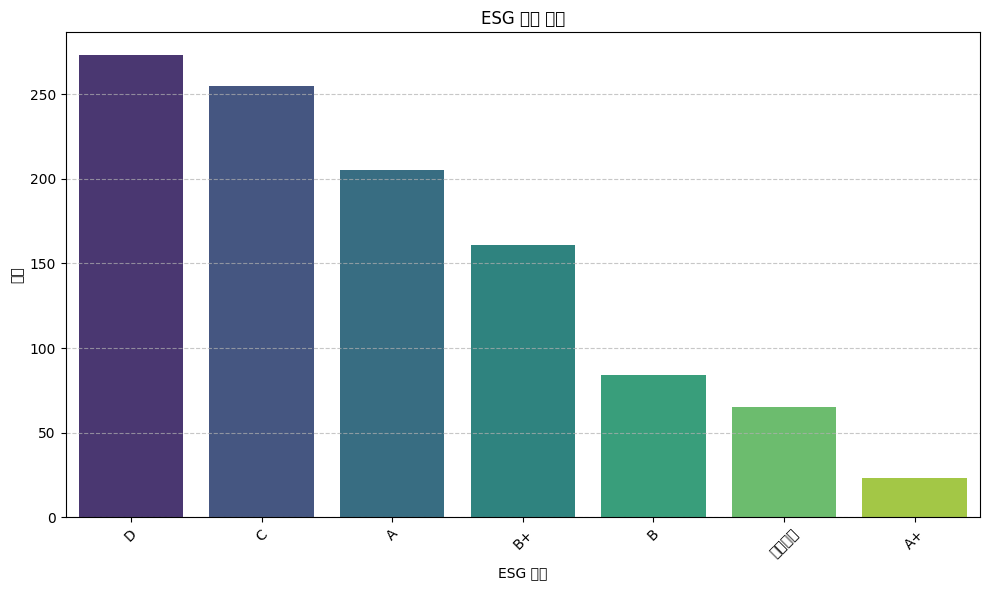

/tmp/ipykernel_63148/2178094390.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='지정구분', order=df['지정구분'].value_counts().index, palette='pastel')
/tmp/ipykernel_63148/2178094390.py:34: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63148/2178094390.py:34: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63148/2178094390.py:34: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63148/2178094390.py:34: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_63148/2178094390.py:34: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(

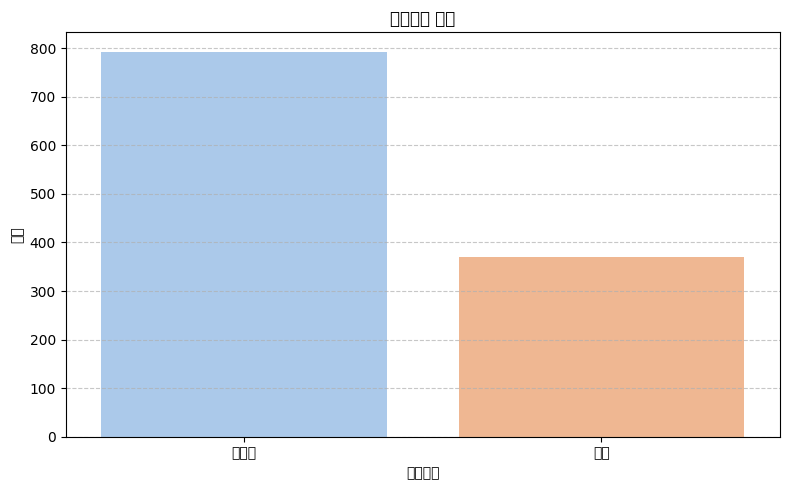

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 범주형 컬럼 리스트 (종목코드, 법인명 제외)
categorical_cols = ['지정구분', '업종명', 'ESG등급', '환경', '사회', '지배구조']

print("\n--- Categorical Columns Analysis ---\n")

for col in categorical_cols:
    print(f"\n--- Column: {col} ---")
    print(f"Unique values: {df[col].nunique()}")
    display(df[col].value_counts(dropna=False).head(10)) # 상위 10개 및 NaN 포함

# ESG 등급 시각화 (예시: ESG 등급)
if 'ESG등급' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='ESG등급', order=df['ESG등급'].value_counts().index, palette='viridis')
    plt.title('ESG 등급 분포')
    plt.xlabel('ESG 등급')
    plt.ylabel('빈도')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 지정구분 시각화 (예시)
if '지정구분' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='지정구분', order=df['지정구분'].value_counts().index, palette='pastel')
    plt.title('지정구분 분포')
    plt.xlabel('지정구분')
    plt.ylabel('빈도')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [28]:
print("\n--- Percentage of Missing Values ---\n")
total_rows = len(df)
missing_percentage = (missing_values_after_conversion / total_rows) * 100
display(missing_percentage[missing_percentage > 0].sort_values(ascending=False))


--- Percentage of Missing Values ---



,0
지배구조,46.965174
환경,46.965174
사회,46.965174
ESG등급,46.965174
에너지 사용량(TJ),42.089552
업종명,42.089552
온실가스 배출량(tCO₂eq),42.089552
지정구분,42.089552
법인명,0.049751
